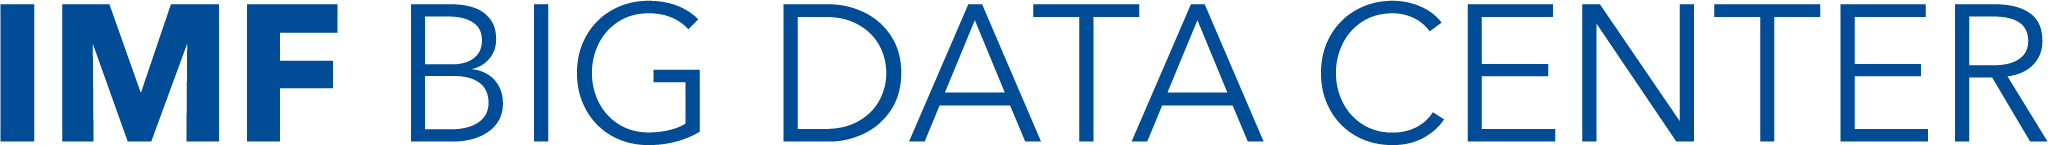

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/imfgit/imf_big_data_workshop_sti26/blob/main/notebooks/BDC_Challenge_Trade_Nowcasting.ipynb)

# Big Data Challenge: Nowcast US Trade values to assess trade tensions

---

<br>**Contributors:**
<br> **Last update:**
<br> **Description:** This notebook is a group challenge to nowcast US trade values and volumes from PortWatch port-call data, BACI unit values and WTO price indexes, benchmarked against the CPB World Trade Monitor and official maritime statistics
<br> **References:**

## Setup

### Mount drive

In [ ]:
# Mounth the drive to access file in the Google Drive folder
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

### Set the path

In [ ]:
# Set the main path for the workshop files

import os

ROOT = "/content/drive/MyDrive/STI 2026"
workshop_path = os.path.join(ROOT, "Day 4-5 - Capstone Project")
data_path = os.path.join(workshop_path, "trade-input-data")

# Check if working
print("Worshop path found: ", os.path.exists(workshop_path))
print("Data path found: ", os.path.exists(data_path))


### Install and import libraries

In [ ]:
%%capture
!pip install sdmx1

In [ ]:
## PortWatch Nowcasting libraries
# Source the functions in the pw_nowcasting_functions.py file
import sys
sys.path.append(workshop_path)

from pw_nowcasting_functions import (
                     ### Functions 1 - Load PortWatch Local Data
                     fetch_portwatch_local, tweak_portwatch_local,

                     ####Functions 2 - Fetch, Tweak and Compile
                     fetch_cpb, tweak_cpb,
                     compile_price_indexes, to_prices, to_laspeyres_price_index,
                     to_value_series,
                     to_volume_weighted_series,
                     fetch_baci_local,

                     #### Functions 3 - Utilities and Calculations
                     bound_dates, to_index,
                     moving_avg, growth_rate, correlate, fetch_and_tweak

                     )

In [ ]:
# Other libraries
import time
import json
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt

### Convenient Plotting function

In [ ]:
def plot_series(ax, s1, s2, label1, label2, title):
    """Plot two time series on the same axis."""
    s1.plot(ax=ax, label=label1, legend=True)
    s2.plot(ax=ax, label=label2, legend=True)
    ax.set_title(title)

### Set the latest month for which we have full data

In [ ]:
LAST_MONTH = '2025-09-30'

### Set Country for this Excercise

In [ ]:
country_iso3 = 'USA'
country_name = 'United States'

## Portwatch data

For the latest PortWatch Data: https://portwatch.imf.org/datasets/959214444157458aad969389b3ebe1a0/about

#### Load data and subset for US

In [ ]:
# PortWatch Aggregated Data: Monthly import/export physical volumes for the 5 ship types

portwatch_local_filepath = os.path.join(data_path, "Daily_Port_Activity_Data_and_Trade_Estimates.csv")
print("Last edit time: ", time.ctime(os.path.getmtime(portwatch_local_filepath)))

portwatch_raw =  fetch_portwatch_local(portwatch_local_filepath)

# Process for US data
portwatch =  tweak_portwatch_local(portwatch_raw,
                                   iso3 = country_iso3, # DATA for the US
                                   end_date=LAST_MONTH)
portwatch.tail()

#### Plot

In [ ]:
# Create a figure for better layout control
plt.figure(figsize=(12, 6))

# --- Export series ---
export_series = (
    portwatch[('cargo', 'export')] +
    portwatch[('dry_bulk', 'export')] +
    portwatch[('tanker', 'export')]
)
export_series.plot(label='Export')

# --- Import series ---
import_series = (
    portwatch[('cargo', 'import')] +
    portwatch[('dry_bulk', 'import')] +
    portwatch[('tanker', 'import')]
)
import_series.plot(label='Import')

# Plot formatting
plt.legend()
plt.title("PortWatch Physical Volumes (World Aggregate)")
plt.ylabel("Metric Tons")
plt.xlabel("")

# Add footnote below the plot
plt.figtext(0.5, -0.02, "Source: IMF PortWatch", ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.show()


##### ❓ **Can you highlight anything from this chart**


## Baci $/MT unit values

#### Load data

In [ ]:
# Load the pre-computed BACI unit values for USA, different country aggregates and individual countries

baci_filepath = os.path.join(data_path, 'baci_usd_per_ton.csv')

baci_usd_per_ton = fetch_baci_local(baci_filepath,
                                    iso3=country_iso3) # USA

baci_usd_per_ton

#### Plot

In [ ]:
# Create two subplots: one for import, one for export
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# --- Plot Import Price Indexes ---
baci_usd_per_ton.loc[country_iso3].xs('import', axis=0, level=1).plot.bar(
    legend=True,
    ax=axs[0],
    title=f"Import $/MT Unit Values by Vessel Type",
    xlabel=''
)

# --- Plot Export Price Indexes ---
baci_usd_per_ton.loc[country_iso3].xs('export', axis=0, level=1).plot.bar(
    legend=True,
    ax=axs[1],
    title=f"Export $/MT Unit Values by Vessel Type",
    xlabel=''
)


# Add a footnote below the entire figure
fig.text(0.5, -0.1, 'Source: IMF PortWatch team using CEEPI BACI data',
         ha='center', va='center', fontsize=10, style='italic');

plt.tight_layout()
plt.show()

##### ❓ **How these Unit Values differ from the ones computed for the World**


##### ❓ **Do they tell anything about the US trade composition**

## Prices

#### Global Price Indexes by Ship Type

> Generate your API Key from the World Trade Organization [WTO API PORTAL](https://apiportal.wto.org/)


In [ ]:
#It is a good practice to store your API Key in CoLab's "SECRET"
#It is similar to an environmental variable.
#(see the key symbol on the left menu)
#The code below imports the API key named 'WTO_API_KEY' without revealing the actual key.

from google.colab import userdata
wto_api_key = userdata.get('WTO_API_KEY')

In [ ]:
# compile_price_indexes function compiles all price indexes dircetly from APIs
# and always return the latest values
price_indexes = compile_price_indexes(wto_api_key=wto_api_key, end_date=LAST_MONTH)

# DATA BACKUP
#price_indexes = pd.read_csv(os.path.join(data_path, 'price_indexes.csv'),
#                            header=[0, 1],
#                            index_col=0)
#price_indexes.index = pd.to_datetime(price_indexes.index)


# Check the columns of the DataFrame
price_indexes.tail()

#### From Price Indexes to Prices


To calculate the change in the average unit value of goods exported/imported by vessel type monthly, we simply multiply the BACI unit values for each group times the price indexes.

Note: Unit values are region/country specific, while price indexes are global.

In [ ]:
prices = to_prices(baci_rel_prices=baci_usd_per_ton, price_indexes=price_indexes)

print(prices.shape)

prices.tail()

#### Plot

In [ ]:
# Get the latest date available in the index
price_indexes.index = pd.to_datetime(price_indexes.index)

latest_date = price_indexes.index.max().strftime('%B %Y')

# Create two subplots: one for import, one for export
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# --- Plot Import Price Indexes ---
price_indexes.xs('import', axis=1, level=1).plot(
    legend=True,
    ax=axs[0],
    title=f"Import Price Indexes by Ship Type\nLast Obs. {latest_date}"
)

# --- Plot Export Price Indexes ---
price_indexes.xs('export', axis=1, level=1).plot(
    legend=True,
    ax=axs[1],
    title=f"Export Price Indexes by Ship Type\nLast Obs. {latest_date}"
)

# Add a footnote below the entire figure
fig.text(0.5, -0.05, 'Source: IMF PortWatch team using WTO/IMF price indexes',
         ha='center', va='center', fontsize=10, style='italic')

plt.tight_layout()
plt.show()

In [ ]:
# Get the latest date available in the index
prices.index = pd.to_datetime(prices.index)

latest_date = prices.index.max().strftime('%B %Y')

# Create two subplots: one for import, one for export
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# --- Plot Import Price Indexes ---
prices.xs('import', axis=1, level=1).plot(
    legend=True,
    ax=axs[0],
    title=f"{country_iso3} Import Prices by Ship Type\nLast Obs. {latest_date}"
)

# --- Plot Export Price Indexes ---
prices.xs('export', axis=1, level=1).plot(
    legend=True,
    ax=axs[1],
    title=f"{country_iso3} Export Prices by Ship Type\nLast Obs. {latest_date}"
)

# Add a footnote below the entire figure
fig.text(0.5, -0.05, 'Source: IMF PortWatch team using BACI unit values and WTO/IMF price indexes',
         ha='center', va='center', fontsize=10, style='italic');

plt.tight_layout()
plt.show()

#### ❓ **Can you think of different import and export prices by type of ship for the US?  🤓**

## Compute PWI Trade Value
This process transforms physical volumes (in metric tons) data from <b>PortWatch</b> into estimated <b>trade values</b> by combining it with BACI unit values and percentage changes in the average unit values.

#### Import/Export Values

In [ ]:
# Compute trade value series from combination of PortWatch import/export physical volumes
# with prices by vessel types. Add the total trade values as well.
values = to_value_series(
    portwatch=portwatch,
    prices=prices
)

values.tail().div(10**9) # divide by 10**9 for the sake of display

#### Convert to Indexes

In [ ]:
value_indexes = to_index(df=values,
                         base_year=2019) # The to_index function normalizes the value time series by setting a base period

# Show the last few rows of the resulting DataFrame
value_indexes.tail()


#### Plots

<h4> 🎯 PortWatch-derived import/export <b>value indexes</b> </h4>

In [ ]:
# Create plot
fig, ax = plt.subplots(figsize=(12, 5))

# --- Plot Value Import/Export Indexes ---
value_indexes[('total', 'import')].plot(
    label="import",
    ax=ax,
    legend=True)
value_indexes[('total', 'export')].plot(
    label="export",
    ax=ax,
    legend=True)

plt.title(f'{country_iso3} Trade Value Index [2019=100]')

# Add 0 line
plt.hlines(y=100,
           xmin=value_indexes.index.min(),
           xmax=value_indexes.index.max(),
           alpha=0.2, colors='grey', linestyles='--')

plt.legend(
    loc='upper left'
)

# Add a footnote below the entire figure
fig.text(0.5, -0.05, 'Source: IMF PortWatch',
         ha='center', va='center', fontsize=10, style='italic')

#### ADD KEY DATES TO THIS PLOT
# Add a Vertical line indicating Liberation Day (April 2, 2025)
plt.vlines(x=pd.to_datetime('2025-04-02'),
           # eye-balled ymin and ymax for the chart
           ymin=80,
           ymax=160,
           alpha=0.2, colors='red', linestyles='-')
# Add Text
plt.annotate(
    'Liberation\nDay',
    xy=(pd.to_datetime('2025-04-02'), 155),
    color='red')

plt.tight_layout()
plt.show()

### ❓ **What is your interpretation of the charts 🤓**





### ❓ **What are other key dates you can think of 🤓**


## Compute PWI Trade Volume
This process transforms import/export trade values (in $) derived in previous step into estimated <b>trade volume  (in constant prices)</b> using import/export price deflators.

#### Import/Export Price Deflators

In [ ]:
# Calculate import/export price indexes deflators using Laspeyres-type index
chpis = to_laspeyres_price_index(portwatch=portwatch, prices=prices)

print(chpis.shape)

chpis.tail()

#### Import/Export Volumes

In [ ]:
volume = to_volume_weighted_series(chained_price_index=chpis, values=values)
volume.tail()

#### Convert to Indexes

In [ ]:
volume_indexes = to_index(df=volume, base_year=2019)
volume_indexes.tail()

#### Plot

<h4> 🎯 PortWatch-derived import/export <b>volume indexes</b> </h4>

In [ ]:
# Create plot
fig, ax = plt.subplots(figsize=(12, 5))

# --- Plot Volume Import/Export Indexes ---
volume_indexes['import'].plot(
    label="import",
    ax=ax,
    legend=True)
volume_indexes['export'].plot(
    label="export",
    ax=ax,
    legend=True)

plt.title(f'{country_iso3} Trade Volume Index [2019=100]')

# Add 0 line
plt.hlines(y=100,
           xmin=volume_indexes.index.min(),
           xmax=volume_indexes.index.max(),
           alpha=0.2, colors='grey', linestyles='--')

# Add a footnote below the entire figure
fig.text(0.5, -0.05, 'Source: IMF PortWatch',
         ha='center', va='center', fontsize=10, style='italic')

plt.tight_layout()
plt.show()

#### ❓ **What is your interpretation of the chart  🤓**



## Combine Import/Export Value and Volume Indexes into a single dataset

In [ ]:
trade_df = (
    pd.concat([value_indexes['total'].rename(columns={c:'value_'+c for c in value_indexes['total'].columns}),
               volume_indexes.rename(columns={c:'volume_'+c for c in volume_indexes.columns})], axis=1)
)

trade_df

In [ ]:
trade_df.to_csv(os.path.join(data_path, f'{country_iso3}_pw_trade_nowcast.csv'))

## Comparison with Official data from CPB World Trade Monitor (Trade for All Mode of Transport)

Source: https://www.cpb.nl/en/worldtrademonitor

In [ ]:
# Get the most recent data from CPB

# PW functions
cpb_value, cpb_volume = fetch_and_tweak(fetch_cpb, tweak_cpb)

print("CPB Estimates for regions: ", cpb_value.index.levels[0].to_list())

# BACKUP files
#cpb_value = (
#    pd.read_csv(os.path.join(data_path, 'cpb_value.csv'))
#    .assign(date=lambda x: pd.to_datetime(x['date']))
#    .set_index(['country', 'date']))

#cpb_volume = (
#    pd.read_csv(os.path.join(data_path, 'cpb_volume.csv'))
#    .assign(date=lambda x: pd.to_datetime(x['date']))
#    .set_index(['country', 'date']))

# Filter for World
cpb_value = cpb_value.loc[country_name]
cpb_volume = cpb_volume.loc[country_name]

cpb_value.tail()

In [ ]:
# Get the most recent date from the CPB
latest_date = pd.to_datetime(cpb_value.index.max()).strftime('%B %Y')

# Create side-by-side subplots for value and volume indexes
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# --- Plot 1: Trade Value Indexes ---
# Plot Import Value Index
cpb_value['import'].plot(
    label=f'{country_iso3} Value Index - Import', legend=True, ax=axs[0]
)

# Plot Export Value Index with title
cpb_value['export'].plot(
    label=f'{country_iso3} Value Index - Export',
    legend=True,
    ax=axs[0],
    title=f"CPB {country_iso3} Trade Value Indexes\nLast Obs. {latest_date}"
)

# --- Plot 2: Trade Volume Indexes ---
# Plot Import Volume Index
cpb_volume['import'].plot(
    label=f'{country_iso3} Volume Index - Import', legend=True, ax=axs[1]
)

# Plot Export Volume Index with title
cpb_volume['export'].plot(
    label=f'{country_iso3} Volume Index - Export',
    legend=True,
    ax=axs[1],
    title=f"CPB {country_iso3} Trade Volume Indexes\nLast Obs. {latest_date}"
)

plt.tight_layout()
plt.show()

#### ❓ **Whoaaaaa 😮 What is that JUMP 🚀 in 2025 Import Values and Volumes**

<h3> 🎯 Compare PortWatch-derived trade value and volume indexes  with CPB indexes </h3>



In [ ]:
pw_indexes_3ma = moving_avg(df=trade_df, period=3)
trade_df.head()

##### Correlations

In [ ]:
# Prepare series and compute correlations - Import Values
imp_val_cbp = cpb_value['import']
imp_val_pw = trade_df['value_import']
imp_correlation = correlate(imp_val_cbp, imp_val_pw)
imp_correlation

In [ ]:
# Prepare series and compute correlations - Export Values
exp_val_cbp = cpb_value['export']
exp_val_pw = trade_df['value_export']
exp_correlation = correlate(exp_val_cbp, exp_val_pw)
exp_correlation

In [ ]:
# Prepare series and compute correlations - Import Volumes
imp_vol_cbp = cpb_volume['import']
imp_vol_pw = trade_df['volume_import']
imp_vol_correlation = correlate(imp_vol_cbp, imp_vol_pw)
imp_vol_correlation


In [ ]:
# Prepare series and compute correlations - Export Volumes
exp_vol_cbp = cpb_volume['export']
exp_vol_pw = trade_df['volume_export']
exp_vol_correlation = correlate(exp_vol_cbp, exp_vol_pw)
exp_vol_correlation

### 🎯 Compare PortWatch-derived <b>value index</b>  vs. CPB <b>value index</b>

In [ ]:
# Format latest date
latest_date = trade_df.index.max().strftime('%B %Y')

# Create Values plots
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

plot_series(
    axs[0], imp_val_pw, imp_val_cbp,
    label1='PW Value 3ma', label2='CPB',
    title=f"Import Value\nLast Obs. {latest_date}; Corr. {imp_correlation:.2f}"
)

plot_series(
    axs[1], exp_val_pw, exp_val_cbp,
    label1='PW Value 3ma', label2='CPB',
    title=f"Export Value\nLast Obs. {latest_date}; Corr. {exp_correlation:.2f}"
)

# Source note and layout
fig.text(0.5, -0.05, "Source: IMF PortWatch, CPB World Trade Monitor", ha='center', fontsize=10, style='italic')
plt.tight_layout()
plt.show()


#### ❓ **What is your interpretation of the chart  🤓**


### 🎯 Compare PortWatch-derived <b>volume index</b>  vs. CPB <b>volume index</b>



In [ ]:
# Format latest date
latest_date = trade_df.index.max().strftime('%B %Y')

# --- Create Volume plots ---
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

plot_series(
    axs[0], imp_vol_pw, imp_vol_cbp,
    label1='PW Volume 3ma', label2='CPB',
    title=f"{country_iso3} Import Volume\nLast Obs. {latest_date}; Corr. {imp_vol_correlation:.2f}"
)

plot_series(
    axs[1], exp_vol_pw, exp_vol_cbp,
    label1='PW Volume 3ma', label2='CPB',
    title=f"{country_iso3} Export Volume\nLast Obs. {latest_date}; Corr. {exp_vol_correlation:.2f}"
)

# Source note and layout
fig.text(0.5, -0.05, "Source: IMF PortWatch, CPB World Trade Monitor", ha='center', fontsize=10, style='italic')
plt.tight_layout()
plt.show()



#### ❓ **What is your interpretation of the chart  🤓**


### What about Official Maritime Data that excludes other mode of Transport?

In [ ]:
# Load Data
us_maritime_imp = pd.read_csv(os.path.join(data_path, 'us_maritime_imp.csv'), thousands=',')
us_maritime_exp = pd.read_csv(os.path.join(data_path, 'us_maritime_exp.csv'), thousands=',')
us_maritime_exp['date'] = pd.to_datetime(us_maritime_exp['Time'], format="%y-%b")
us_maritime_imp['date'] = pd.to_datetime(us_maritime_imp['Time'], format="%b-%y")

us_maritime_df = pd.merge(
    us_maritime_exp[['date', 'Vessel Total Exports Value ($US)']],
    us_maritime_imp[['date', 'Vessel Customs Value (Gen) ($US)']],
    on='date'
).set_index('date')

# Create indexes with 2019 base year
us_maritime_df = to_index(us_maritime_df)

us_maritime_df

In [ ]:
# Get the most recent date
latest_date = pd.to_datetime(us_maritime_df.index.max()).strftime('%B %Y')

# Create plot for value indexes
fig, ax = plt.subplots(figsize=(12, 5))

# --- Plot 1: Trade Value Indexes ---
# Plot Import Value Index
us_maritime_df['Vessel Customs Value (Gen) ($US)'].plot(
    label=f'{country_iso3} Maritime Value Index - Import', legend=True, ax=ax
)

# Plot Export Value Index with title
us_maritime_df['Vessel Total Exports Value ($US)'].plot(
    label=f'{country_iso3} Maritime Value Index - Export',
    legend=True,
    ax=ax,
    title=f"{country_iso3} Customs Trade Value Indexes\nLast Obs. {latest_date}"
)

plt.tight_layout()
plt.show()

#### Correlations

In [ ]:
# Prepare series and compute correlations - Import Values
imp_val_mar = us_maritime_df['Vessel Customs Value (Gen) ($US)']
imp_val_pw = trade_df['value_import'].loc[:imp_val_mar.index.max()]
imp_correlation = correlate(imp_val_mar, imp_val_pw)
imp_correlation

In [ ]:
# Prepare series and compute correlations - Export Values
exp_val_mar = us_maritime_df['Vessel Customs Value (Gen) ($US)']
exp_val_pw = trade_df['value_export'].loc[:exp_val_mar.index.max()]
exp_correlation = correlate(exp_val_mar, exp_val_pw)
exp_correlation

### 🎯 Compare PortWatch-derived <b>value index</b>  vs. Official US Maritime <b>value index</b>

In [ ]:
# Format latest date
latest_date = trade_df.index.max().strftime('%B %Y')

# Create Values plots
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

plot_series(
    axs[0], imp_val_pw, imp_val_mar,
    label1='PW Value 3ma', label2='US Official Maritime',
    title=f"Import Value\nLast Obs. {latest_date}; Corr. {imp_correlation:.2f}"
)

plot_series(
    axs[1], exp_val_pw, exp_val_mar,
    label1='PW Value 3ma', label2='US Official Maritime',
    title=f"Export Value\nLast Obs. {latest_date}; Corr. {exp_correlation:.2f}"
)

# Source note and layout
fig.text(0.5, -0.05, "Source: IMF PortWatch, US Official Data", ha='center', fontsize=10, style='italic')
plt.tight_layout()
plt.show()


#### ❓ **What is your interpretation of the chart  🤓**

## Annex

### Data Sources

The notebook requires input data from several sources:
| Input Source                          | Link                                                                 |
|---------------------------------|----------------------------------------------------------------------|
| IMF PortWatch                   | [portwatch.imf.org](https://portwatch.imf.org/pages/data-and-methodology) |
| IMF Primary Commodity Prices    | [IMF PCP](https://www.imf.org/en/Research/commodity-prices-)        |
| CEPII - Base pour l'Analyse du Commerce International                           | [CEPII-BACI](https://www.cepii.fr/CEPII/en/bdd_modele/bdd_modele_item.asp?id=37)                                                 |
| US CPI (U.S. Bureau of Labor Statistics API)                | [api.bls.gov](https://api.bls.gov/publicAPI/v1/timeseries/data/)        |
| Federal Reserve Bank of Cleveland CPI                   | [clevelandfed.org](https://www.clevelandfed.org/indicators-and-data/inflation-nowcasting) |
| WTO -  Import and Export price indices of manufactured goods       | [api.wto.org](https://api.wto.org/timeseries/v1/data?)              |
| CPB World Trade Monitor         | [cpb.nl](https://www.cpb.nl/en/worldtrademonitor)                   |


### Country Composition of WEO Groups
Source: [IMF World Economic Outlook Database (April 2023)](https://www.imf.org/en/Publications/WEO/weo-database/2023/April/groups-and-aggregates)


| Source | Code | Name                                                | # Countries |
|:-------:|:----:|:---------------------------------------------------|-------------:|
| WEO | WLD | World | All |
| WEO | 110 | Advanced Economies | 41 |
| WEO | 163 | Euro Area | 20 |
| WEO | 119 | Major Advanced Economies (G7) | 7 |
| WEO | 123 | Other Advanced Economies (Advanced Economies excluding G7 and Euro Area) | 17 |
| WEO | 998 | European Union | 27 |
| WEO | 510 | ASEAN-5 | 5 |
| WEO | 200 | Emerging Market and Developing Economies | 0 |
| WEO | 505 | Emerging and Developing Asia | 0 |
| WEO | 903 | Emerging and Developing Europe | 0 |
| WEO | 205 | Latin America and the Caribbean | 0 |
| WEO | 400 | Middle East and Central Asia | 0 |
| WEO | 603 | Sub-Saharan Africa | 0 |
| APD | 511 | Asian Advanced Economies excluding Japan | 7 |
| APD | 512 | Asian Emerging Markets excluding China | 25 |
| APD | 513 | ASEAN-10 | 9 |
